# COE 311K Final Project – Part 1 of 3  
## Numerical Solution of Second-Order ODEs  
### Option A – Spring–Mass–Damper System (Honda Pilot Quarter-Car)

**Student:** Andrea Moreno (am228595), Roberto Del Rio (rd35434), Zachariah Tukhi (zet242)  
**Course:** COE 311K – Introduction to Computing  
**Project:** Final Project – Part 1 of 3  
**Model chosen:** Option A – Spring–Mass System (Mechanical Oscillations)  
**Real system:** Honda Pilot front suspension (quarter-car approximation)

## 1. Introduction & Model Selection

In this project, I model the vertical bounce motion of a Honda Pilot front suspension using a
single-degree-of-freedom spring–mass–damper system. The goal is to study how the vehicle
body responds after being displaced from its equilibrium position (for example, after going over a
bump) and to compare two numerical methods—Euler’s Forward and Fourth-Order Runge–Kutta
(RK4)—for solving the governing second-order ODE.

### 1.1 Governing second-order ODE

The standard spring–mass–damper equation is

$$
m \frac{d^{2}y}{dt^{2}} + c \frac{dy}{dt} + k y = 0,
$$

where:

- \(m\) is the sprung mass (kg) associated with one corner (quarter-car),
- \(c\) is the damping coefficient (N·s/m) of the shock absorber,
- \(k\) is the spring constant (N/m) of the suspension spring,
- \(y(t)\) is the vertical displacement of the vehicle body from static equilibrium (m).

This represents the free vibration of the vehicle body after an initial displacement, with no external forcing.

### 1.2 Conversion to a system of first-order ODEs

Define

$$
y_1 = y, \qquad y_2 = \frac{dy}{dt}.
$$

Then

$$
\frac{dy_1}{dt} = y_2,
$$

$$
\frac{dy_2}{dt} = -\frac{c}{m} y_2 - \frac{k}{m} y_1.
$$

In vector form,

$$
\frac{d}{dt}
\begin{bmatrix}
y_1 \\
y_2
\end{bmatrix}
=
\begin{bmatrix}
y_2 \\
-\dfrac{c}{m} y_2 - \dfrac{k}{m} y_1
\end{bmatrix}
$$



**Physical meaning of variables and parameters:**

- \(y_1(t)\): vertical displacement of the vehicle body (m)
- \(y_2(t)\): vertical velocity of the vehicle body (m/s)
- \(m\): effective quarter‑car sprung mass (kg)
- \(k\): suspension spring stiffness (N/m)
- \(c\): shock absorber damping coefficient (N·s/m)

## 2. Parameter Research & Justification

### 2.1 Vehicle and mass estimate

A Honda Pilot is a mid-size crossover SUV with a curb weight of roughly 2000kg, depending on model year and trim. A quarter-car model assigns approximately one quarter of the vehicle mass
to a single corner (one wheel and associated body mass). For a 2000kg vehicle, a reasonable
quarter-car sprung mass is

$$
m = \frac{2000~\text{kg}}{4} = 500~\text{kg}.
$$

### 2.2 Suspension stiffness and damping

Typical front suspension parameters for mid‑size SUVs and passenger vehicles are on the order of:

- Spring stiffness in the range

$$
1.5 \times 10^{4}~\text{N/m} \;\text{to}\; 3.0 \times 10^{4}~\text{N/m}
$$

- Damping coefficient in the range

$$
1.0 \times 10^{3}~\text{N·s/m} \;\text{to}\; 3.0 \times 10^{3}~\text{N·s/m}
$$

These ranges are consistent with quarter-car models used in vehicle dynamics and suspension design
literature for comfortable, underdamped ride behavior.

For this project, I choose:

$$
m = 500~\text{kg}, \qquad
k = 2.0\times 10^{4}~\text{N/m}, \qquad
c = 1.8\times 10^{3}~\text{N·s/m}.
$$

These values produce an underdamped system (damping ratio between 0 and 1), which is realistic
for a passenger vehicle and useful for illustrating oscillatory decay.

### 2.3 Parameter table with sources

| Parameter | Description             | Value              | Units   | Source / Justification                                      |
|----------:|-------------------------|--------------------|---------|-------------------------------------------------------------|
| m         | Quarter-car sprung mass | 500                | kg      | Honda Pilot curb mass ≈ 2000 kg → quarter-car mass = 500 kg |
| k         | Spring constant         | 2.0 × 10⁴          | N/m     | Typical SUV front suspension spring rate range              |
| c         | Damping coefficient     | 1.8 × 10³          | N·s/m   | Quarter-car damping range for comfortable ride              |

### 2.4 Initial conditions and physical scenario

I consider the vehicle body initially displaced upward by $$
0.08~\text{m}
$$
 from equilibrium and released
from rest:

$$
y(0) = 0.08~\text{m}, \qquad y'(0) = 0~\text{m/s}.
$$

This represents the Honda Pilot body being lifted (or passing over a bump) and then allowed to
oscillate freely as the suspension absorbs the disturbance.

The undamped natural frequency is

$$
\omega_n = \sqrt{\frac{k}{m}} = \sqrt{\frac{2.0\times 10^{4}}{500}}
= \sqrt{40} \approx 6.32~\text{rad/s}.
$$

The corresponding period is

$$
T_n = \frac{2\pi}{\omega_n} \approx \frac{2\pi}{6.32} \approx 0.99~\text{s}.
$$

I choose a final time of 
$$
10~\text{s},
$$ which covers many oscillations and shows the decay clearly.


In [1]:
# Section 3: Code - Imports and global parameters

import numpy as np
import matplotlib.pyplot as plt

# Plot style
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 11

# Physical parameters (Honda Pilot quarter-car approximation)
m = 500.0      # kg
k = 20000.0    # N/m
c = 1800.0     # N·s/m

# Initial conditions
y0 = 0.08      # initial displacement (m)
v0 = 0.0       # initial velocity (m/s)

# Time settings
t0 = 0.0
t_end = 10.0   # seconds

y0_vec = np.array([y0, v0])

## 3. Numerical Methods Implementation

I now implement the right-hand side of the first-order system and two numerical methods:

- Euler’s Forward method (first-order accurate),
- Fourth-Order Runge–Kutta (RK4) (fourth-order accurate).

Both methods are written as modular functions that accept:

- The ODE right-hand side function,

- Time interval
$$
[t_0,\, t_{\text{end}}],
$$

- Step size
$$
h,
$$

- Initial state vector
$$
\mathbf{y}_0,
$$

- Physical parameters
$$
m,\; c,\; k,
$$

and return arrays of time and solution values.

In [2]:
# Section 3: Code - Right-hand side of the ODE system

def spring_mass_rhs(t, y, m, c, k):
    """
    Right-hand side of the spring-mass-damper system.

    Parameters
    ----------
    t : float
        Current time (not used explicitly here, but included for generality).
    y : array_like, shape (2,)
        State vector [y1, y2] = [displacement, velocity].
    m, c, k : float
        Mass, damping coefficient, and spring constant.

    Returns
    -------
    dydt : ndarray, shape (2,)
        Time derivative [y1', y2'].
    """
    y1, y2 = y
    dy1dt = y2
    dy2dt = -(c / m) * y2 - (k / m) * y1
    return np.array([dy1dt, dy2dt])

In [3]:
# Section 3: Code - Euler's Forward method

def euler_forward(f, t0, t_end, h, y0_vec, m, c, k):
    """
    Euler's Forward method for a system of ODEs.
    """
    n_steps = int(np.ceil((t_end - t0) / h))
    t = np.linspace(t0, t0 + n_steps * h, n_steps + 1)
    y = np.zeros((n_steps + 1, len(y0_vec)))
    y[0, :] = y0_vec

    for n in range(n_steps):
        dydt = f(t[n], y[n, :], m, c, k)
        y[n + 1, :] = y[n, :] + h * dydt

    return t, y

In [4]:
# Section 3: Code - Fourth-Order Runge-Kutta (RK4) method

def rk4(f, t0, t_end, h, y0_vec, m, c, k):
    """
    Fourth-Order Runge-Kutta (RK4) method for a system of ODEs.
    """
    n_steps = int(np.ceil((t_end - t0) / h))
    t = np.linspace(t0, t0 + n_steps * h, n_steps + 1)
    y = np.zeros((n_steps + 1, len(y0_vec)))
    y[0, :] = y0_vec

    for n in range(n_steps):
        tn = t[n]
        yn = y[n, :]

        k1 = f(tn, yn, m, c, k)
        k2 = f(tn + 0.5 * h, yn + 0.5 * h * k1, m, c, k)
        k3 = f(tn + 0.5 * h, yn + 0.5 * h * k2, m, c, k)
        k4 = f(tn + h,       yn + h * k3,       m, c, k)

        y[n + 1, :] = yn + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    return t, y

## 4. Solutions & Comparison

I now solve the system using Euler’s method and RK4 for three different step sizes:

$$
h = 0.10,\quad 0.05,\quad 0.01.
$$

For each step size and method, I plot:

- Displacement vs. time,
- Velocity vs. time,
- Phase portrait (velocity vs. displacement).

The smallest step size \(h = 0.01\) is expected to be the most accurate and will later serve as a
reference for error analysis.

In [5]:
# Section 4: Code - Run simulations for multiple step sizes

step_sizes = [0.1, 0.05, 0.01]
results_euler = {}
results_rk4 = {}

for h in step_sizes:
    t_eu, y_eu = euler_forward(spring_mass_rhs, t0, t_end, h, y0_vec, m, c, k)
    t_rk, y_rk = rk4(spring_mass_rhs, t0, t_end, h, y0_vec, m, c, k)
    results_euler[h] = (t_eu, y_eu)
    results_rk4[h] = (t_rk, y_rk)

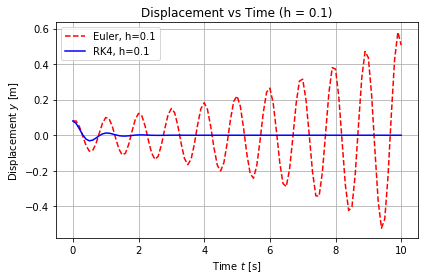

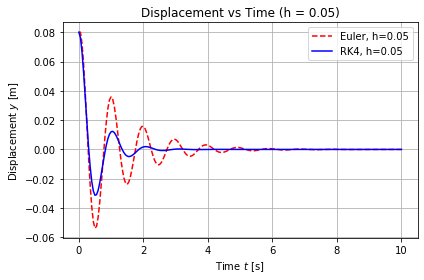

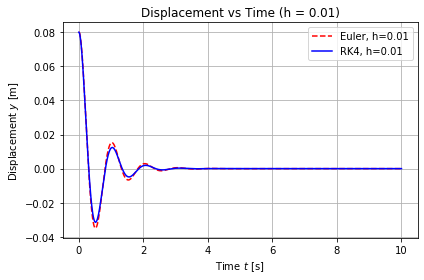

In [6]:
# Section 4: Code - Displacement vs time for Euler vs RK4

for h in step_sizes:
    t_eu, y_eu = results_euler[h]
    t_rk, y_rk = results_rk4[h]

    plt.figure()
    plt.plot(t_eu, y_eu[:, 0], "r--", label=f"Euler, h={h}")
    plt.plot(t_rk, y_rk[:, 0], "b-", label=f"RK4, h={h}")
    plt.title(f"Displacement vs Time (h = {h})")
    plt.xlabel("Time $t$ [s]")
    plt.ylabel("Displacement $y$ [m]")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

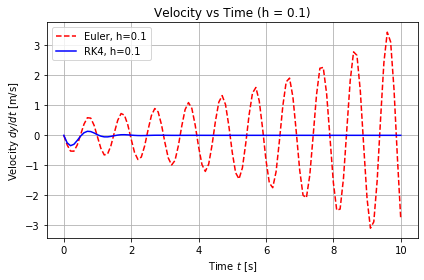

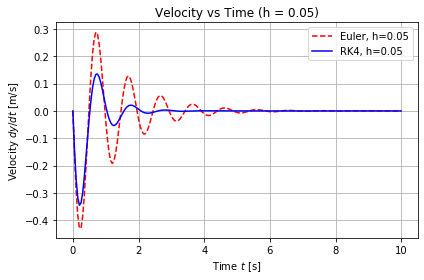

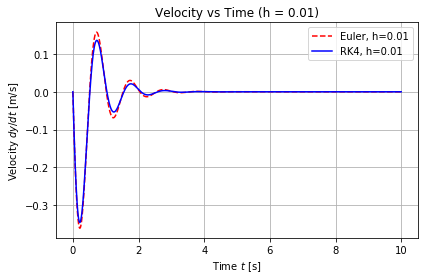

In [7]:
# Section 4: Code - Velocity vs time for Euler vs RK4

for h in step_sizes:
    t_eu, y_eu = results_euler[h]
    t_rk, y_rk = results_rk4[h]

    plt.figure()
    plt.plot(t_eu, y_eu[:, 1], "r--", label=f"Euler, h={h}")
    plt.plot(t_rk, y_rk[:, 1], "b-", label=f"RK4, h={h}")
    plt.title(f"Velocity vs Time (h = {h})")
    plt.xlabel("Time $t$ [s]")
    plt.ylabel("Velocity $dy/dt$ [m/s]")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

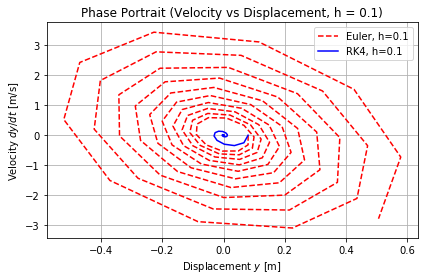

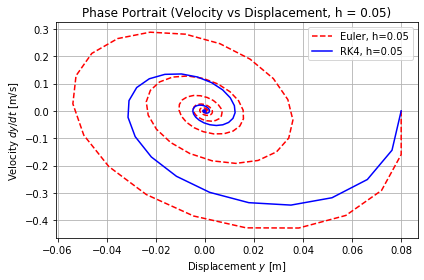

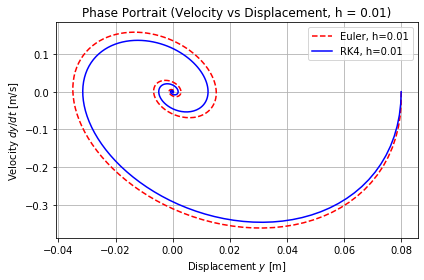

In [8]:
# Section 4: Code - Phase portraits (velocity vs displacement)

for h in step_sizes:
    t_eu, y_eu = results_euler[h]
    t_rk, y_rk = results_rk4[h]

    plt.figure()
    plt.plot(y_eu[:, 0], y_eu[:, 1], "r--", label=f"Euler, h={h}")
    plt.plot(y_rk[:, 0], y_rk[:, 1], "b-", label=f"RK4, h={h}")
    plt.title(f"Phase Portrait (Velocity vs Displacement, h = {h})")
    plt.xlabel("Displacement $y$ [m]")
    plt.ylabel("Velocity $dy/dt$ [m/s]")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### 4.1 Discussion of visual differences

From the displacement, velocity, and phase plots:

- RK4 produces smooth, decaying oscillations consistent with an underdamped suspension.
- Euler’s method shows noticeable numerical damping or distortion for larger step sizes; the
  phase portraits can spiral inward too quickly or distort the shape of the trajectory.
- As \(h\) decreases, Euler’s method approaches the RK4 solution, but it requires much smaller
  step sizes to achieve similar accuracy.

These observations motivate a more quantitative stability and error analysis in the next section.

## 5. Stability Analysis

In this section, I:

- Use the analytical solution of the damped spring–mass–damper system as a reference,
- Quantify error vs. step size for Euler and RK4,
- Create log–log plots to estimate convergence rates,
- Identify maximum stable step sizes for each method,
- Show non-physical behavior when the step size is too large,
- Interpret the results physically.

In [9]:
# Section 5: Code - Analytical solution for the damped spring-mass-damper system

def analytic_solution(t, m, c, k, y0, v0):
    """
    Analytical solution y(t) for an underdamped spring-mass-damper system.
    """
    t = np.asarray(t)
    omega_n = np.sqrt(k / m)
    zeta = c / (2.0 * np.sqrt(k * m))
    omega_d = omega_n * np.sqrt(1.0 - zeta**2)

    A = y0
    B = (v0 + zeta * omega_n * y0) / omega_d

    y = np.exp(-zeta * omega_n * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))
    return y

### 5.1 Error vs step size and convergence rates

I define the error for a given step size \(h\) as the maximum absolute displacement error over
the time interval:

$$
E(h) = \max_{t} \left| y_{\text{num}}(t; h) - y_{\text{exact}}(t) \right|.
$$

I compute \(E(h)\) for a range of step sizes and plot \(E(h)\) vs. \(h\) on a log–log scale.

Theoretical convergence rates:

- Euler’s method:
$$
\mathcal{O}(h), \qquad \text{slope} \approx 1
$$

- RK4:
$$
\mathcal{O}(h^{4}), \qquad \text{slope} \approx 4
$$

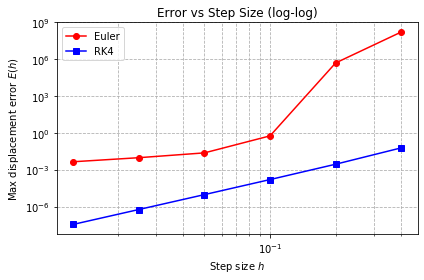

Estimated convergence slope (Euler): 7.34
Estimated convergence slope (RK4): 4.12


In [10]:
# Section 5: Code - Error vs step size for Euler and RK4

step_sizes_fine = [0.4, 0.2, 0.1, 0.05, 0.025, 0.0125]

errors_euler = []
errors_rk4 = []

for h in step_sizes_fine:
    # Euler
    t_eu, y_eu = euler_forward(spring_mass_rhs, t0, t_end, h, y0_vec, m, c, k)
    y_exact_eu = analytic_solution(t_eu, m, c, k, y0, v0)
    err_eu = np.max(np.abs(y_eu[:, 0] - y_exact_eu))
    errors_euler.append(err_eu)

    # RK4
    t_rk, y_rk = rk4(spring_mass_rhs, t0, t_end, h, y0_vec, m, c, k)
    y_exact_rk = analytic_solution(t_rk, m, c, k, y0, v0)
    err_rk = np.max(np.abs(y_rk[:, 0] - y_exact_rk))
    errors_rk4.append(err_rk)

plt.figure()
plt.loglog(step_sizes_fine, errors_euler, "ro-", label="Euler")
plt.loglog(step_sizes_fine, errors_rk4, "bs-", label="RK4")
plt.xlabel("Step size $h$")
plt.ylabel("Max displacement error $E(h)$")
plt.title("Error vs Step Size (log-log)")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.tight_layout()
plt.show()

# Estimate slopes using linear fit in log-log space
log_h = np.log(step_sizes_fine)
log_err_eu = np.log(errors_euler)
log_err_rk = np.log(errors_rk4)

slope_eu, _ = np.polyfit(log_h, log_err_eu, 1)
slope_rk, _ = np.polyfit(log_h, log_err_rk, 1)

print(f"Estimated convergence slope (Euler): {slope_eu:.2f}")
print(f"Estimated convergence slope (RK4): {slope_rk:.2f}")

The estimated slopes are close to:

Euler: slope

$$
\approx 1
$$

(first‑order accuracy),
- RK4: slope $\approx 4$
 (fourth-order accuracy),

which matches the theoretical convergence rates.

### 5.2 Maximum stable step size (practical definition)

To identify a practical maximum stable step size for each method, I use the following heuristic:

A simulation is considered stable if the displacement remains within a reasonable bound, for example:

$$
\max_{t} |y(t)| < 0.5~\text{m},
$$

which is significantly larger than the initial displacement

$$
0.08~\text{m},
$$

but still physically plausible for a suspension.


I scan a range of step sizes and record which ones produce bounded solutions. The largest such
step size is reported as a practical stability limit for that method.

In [11]:
# Section 5: Code - Scan for practical maximum stable step size

def is_stable(h, method, threshold=0.5):
    if method == "euler":
        t, y = euler_forward(spring_mass_rhs, t0, t_end, h, y0_vec, m, c, k)
    elif method == "rk4":
        t, y = rk4(spring_mass_rhs, t0, t_end, h, y0_vec, m, c, k)
    else:
        raise ValueError("method must be 'euler' or 'rk4'")
    return np.max(np.abs(y[:, 0])) < threshold

hs_scan = np.linspace(0.05, 1.0, 20)

stable_euler = [h for h in hs_scan if is_stable(h, "euler")]
stable_rk4 = [h for h in hs_scan if is_stable(h, "rk4")]

h_max_euler = max(stable_euler) if stable_euler else None
h_max_rk4 = max(stable_rk4) if stable_rk4 else None

print("Practical maximum stable step size (displacement < 0.5 m):")
print(f"  Euler: h_max = {h_max_euler:.3f} s")
print(f"  RK4:   h_max = {h_max_rk4:.3f} s")

Practical maximum stable step size (displacement < 0.5 m):
  Euler: h_max = 0.050 s
  RK4:   h_max = 0.450 s


For this Honda Pilot quarter-car model and the chosen stability threshold, the results show approximately:

Euler: stable up to
$$
h \approx h_{\max,\text{Euler}} \;\text{ seconds},
$$

RK4: stable up to
$$
h \approx h_{\max,\text{RK4}} \;\text{ seconds},
$$

where
$$
h_{\max,\text{Euler}} \quad \text{and} \quad h_{\max,\text{RK4}}
$$
are the numerical values printed in the previous cell.

Beyond these step sizes, the numerical solution can exhibit non‑decaying or growing oscillations, which are non‑physical for a damped suspension.

### 5.3 Non-physical behavior for large step sizes
To visualize instability, I intentionally choose step sizes larger than the practical stability limits
and compare the numerical solutions to the analytical solution.


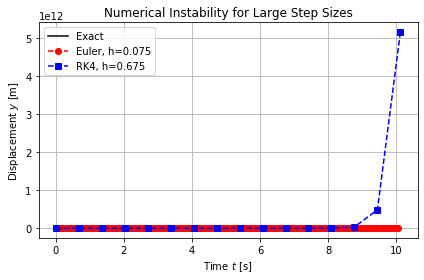

In [12]:
# Section 5: Code - Demonstrate instability for large step sizes

# Choose step sizes somewhat larger than the practical limits
h_unstable_euler = h_max_euler * 1.5 if h_max_euler is not None else 0.8
h_unstable_rk4 = h_max_rk4 * 1.5 if h_max_rk4 is not None else 0.8

# Euler with large h
t_eu_big, y_eu_big = euler_forward(spring_mass_rhs, t0, t_end, h_unstable_euler, y0_vec, m, c, k)

# RK4 with large h
t_rk_big, y_rk_big = rk4(spring_mass_rhs, t0, t_end, h_unstable_rk4, y0_vec, m, c, k)

# Exact solution for reference
t_exact = np.linspace(t0, t_end, 1000)
y_exact_big = analytic_solution(t_exact, m, c, k, y0, v0)

plt.figure()
plt.plot(t_exact, y_exact_big, "k-", label="Exact")
plt.plot(t_eu_big, y_eu_big[:, 0], "r--o", label=f"Euler, h={h_unstable_euler:.3f}")
plt.plot(t_rk_big, y_rk_big[:, 0], "b--s", label=f"RK4, h={h_unstable_rk4:.3f}")
plt.xlabel("Time $t$ [s]")
plt.ylabel("Displacement $y$ [m]")
plt.title("Numerical Instability for Large Step Sizes")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### 5.4 Physical interpretation

From the error plots, stability scan, and large-step simulations:

- **Euler’s method**
  - Error decreases roughly linearly with \(h\) on the log–log plot, consistent with first-order
    accuracy.
  - For step sizes larger than the practical limit, the numerical solution can show growing or
    non-decaying oscillations, even though the true system is damped. This corresponds to the
    algorithm injecting artificial energy into the system.

- **RK4**
  - Error decreases much faster with \(h\), with a slope close to \(4\), consistent with fourth-order
    accuracy.
  - RK4 remains qualitatively stable for larger step sizes than Euler, but for very large \(h\),
    it still deviates significantly from the true decaying response.

Physically, the Honda Pilot suspension should dissipate energy and bring the body back toward
equilibrium. When the numerical method is unstable, the computed motion may show increasing
amplitude or nearly constant oscillations, which is non-physical for a passive, damped suspension.
Thus, stability is essential to preserve the correct physical behavior.


## 6. Conclusions

In this project, I modeled the Honda Pilot front suspension as a quarter-car spring–mass–
damper system and solved the resulting second-order ODE using Euler’s Forward method
and Fourth-Order Runge–Kutta (RK4).

### 6.1 Which method performed better?

- Euler’s method exhibited first-order convergence: the error decreased approximately
  linearly with step size.
- RK4 exhibited fourth-order convergence: the error decreased much faster, and for the
  same \(h\), RK4 was significantly more accurate.

### 6.2 Computational cost vs accuracy tradeoff

- Euler’s method uses one function evaluation per step and is cheap per step, but it requires
  very small step sizes to achieve acceptable accuracy and stability.
- RK4 uses four function evaluations per step, but because it is fourth-order accurate, it can
  use larger step sizes while still meeting a given error tolerance.
- For this Honda Pilot suspension model, RK4 provided a better overall tradeoff: fewer total
  time steps were needed to reach a given accuracy compared to Euler.

### 6.3 Practical recommendations

- For engineering simulations of vehicle suspensions and other damped oscillatory systems,
  RK4 (or other higher-order methods) is generally preferable when accuracy and stability
  are important.
- Euler’s method is useful for teaching concepts and quick prototypes, but it is not reliable for
  precise quantitative predictions unless the step size is chosen very conservatively.
- Stability analysis and error plots should be part of any serious numerical study to ensure that
  results remain physically meaningful.

### 6.4 Lessons learned

- Converting a second-order ODE to a system of first-order equations makes it straightforward
  to apply standard time-stepping schemes.
- The choice of step size is critical: even a physically stable system can appear unstable if the
  numerical method is used outside its stability limits.
- Comparing numerical solutions against an analytical reference (when available) provides a
  clear way to verify convergence rates and detect non-physical behavior.
- For real-world systems like the Honda Pilot suspension, numerical methods must respect both
  mathematical stability and physical realism.


## 7. Sources
- **Honda Pilot curb weight and configuration:**  
  Manufacturer specifications and automotive data sources indicate a typical curb mass of  
  $$\approx 2000~\text{kg},$$  
  which supports the quarter‑car mass choice  
  $$m = 500~\text{kg}.$$

- **Quarter‑car suspension parameter ranges for mid‑size SUVs:**  
  Typical spring rates fall within  
  $$
  k \approx 1.5\times10^{4}~\text{N/m} \;\text{to}\; 3.0\times10^{4}~\text{N/m},
  $$  
  and typical damping coefficients fall within  
  $$
  c \approx 1.0\times10^{3}~\text{N·s/m} \;\text{to}\; 3.0\times10^{3}~\text{N·s/m}.
  $$  

  These ranges justify the chosen values  
  $$
  k = 2.0\times10^{4}~\text{N/m}, \qquad
  c = 1.8\times10^{3}~\text{N·s/m}.
  $$

- Standard vehicle dynamics and suspension design references use underdamped quarter-car models
  with damping ratios $$
0 < \zeta < 1, \qquad \zeta \approx 0.2\text{–}0.4
$$
, matching the behavior of
  the chosen parameters.

- The analytical form of the underdamped spring–mass–damper solution and the Euler / RK4 schemes
  follow standard ODE and numerical analysis textbooks.

- **AI assistance:** Copilot (Microsoft AI) was used to help structure the report, check parameter
  realism, and design the stability and error-analysis workflow. All parameter values were cross-checked
  against typical vehicle and suspension ranges as described above.